# OpenFASoC: Digital LDO Generator

<a href="https://colab.research.google.com/github/alibillalhammoud/OpenFASOC/blob/main/docs/source/notebooks/ldo-gen/LDO_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```
OpenFASOC Team, November 2022
SPDX-License-Identifier: Apache-2.0
```


|Name|Affiliation|IEEE Member|SSCS Member|
|:--:|:----------:|:----------:|:----------:|
|Mehdi Saligane (Advisor) <br /> Email ID: mehdi@umich.edu|University of Michigan|Yes|Yes|
|Ali Hammoud (Lead) <br /> Email ID: alibilal@umich.edu|University of Michigan|Yes|No|
|Pranav Lulu <br /> Email ID: pranavl@umich.edu | University of Michigan|No|No


## Introduction
Welcome!  
This notebook[^1] serves as an introduction to the LDO generator: an open-source silicon generator part of [OpenFASoC](https://github.com/idea-fasoc/OpenFASOC) - An open-source framework for autonomous generation of Digital LDO. A cell-based design methodology is employed to allow full synthesizability and compatibility with computer-aided designs (CADs) flow and advanced technology nodes. Furthermore, the generator automates the design flow end-to-end in Python and supports designing completely with open-source CAD tools.

**_Index Terms:_** Circuit generator , open source, synthesizable design, digital LDO.

Citation:  
Tutu Ajayi et al., "An Open-source Framework for Autonomous SoC Design with Analog Block Generation," 2020 IFIP/IEEE 28th International Conference on Very Large Scale Integration (VLSI-SOC), 2020, pp. 141-146.  

[^1]: This notebook is targeted at users of all professional backgrounds aiming to learn how to *code* their chips. The goal is to go through all the steps of generating the LDO and an overview of the simulation results. 

## Digital LDO
### Purpose (Basic)
DLDO (Digital Low Dropout Voltage Regulator) allows for high efficiency custom voltage operation. Digital LDO is one preferred method for generating custom voltages on chip because it allows for regulated voltage level (VREG) near the source voltage level (VIN) and it avoids large passive components used in other analog voltage regulators. The digital design is easier to integrate. The function of the LDO is to ensure the VREG voltage output remains at a stable value equal to the reference voltage VREF. The input voltage VIN is used to drive the output VREG; VIN can be set to VDD or another voltage source.  

Fundamentally, the DLDO is a closed loop control system with:
1.   A sensor that produces an error (voltage comparison) of the closed-loop-feedback (VREG) signal vs the desired reference value (VREF).
2.   A controller which interprets the error and adjusts the power delivery array.
3.   A tunable power delivery array which can quickly adjust the output voltage (VREG) based on the controller input.

Below is a high-level diagram of the design.

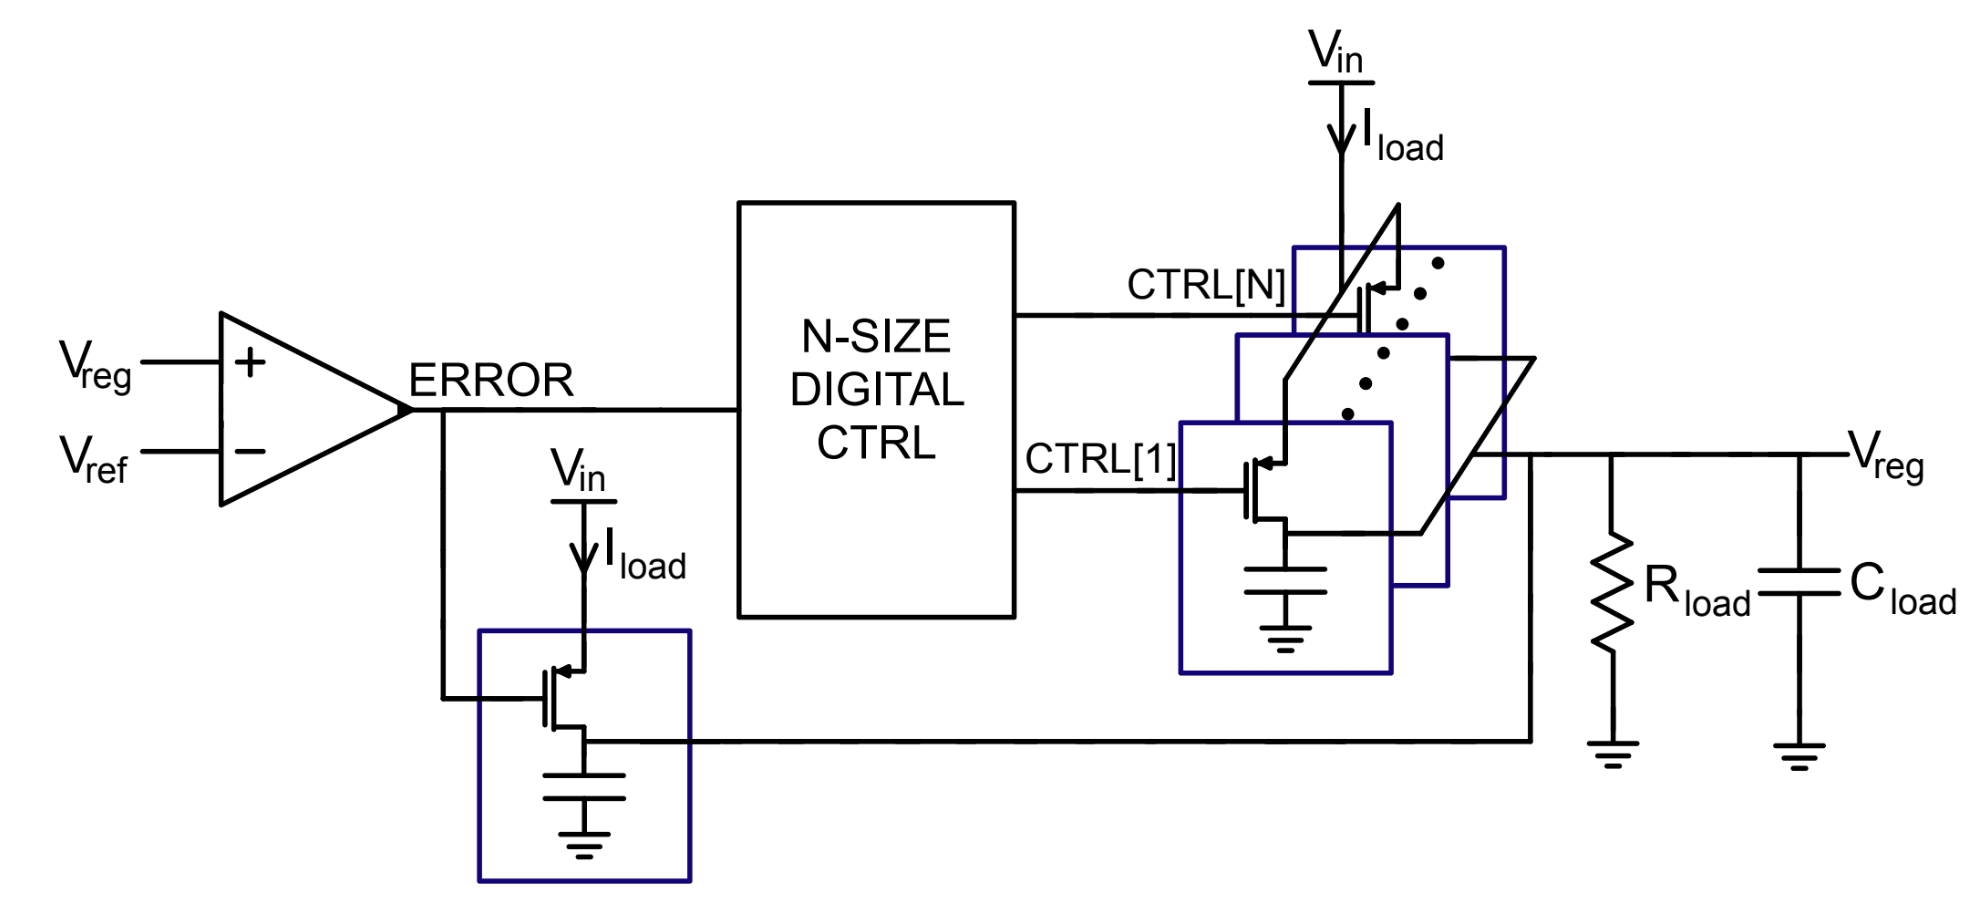

### Applying OpenFASoC to Digital LDO
The OpenFASoC suite of generators achieve high quality and highly automated designs by combining "auxilary" cells with automatically generated components. The digital LDO has four such auxilary cells:

#### VREF Gen Block
Rather than requiring additional circuitry outside the DLDO design to generate the VREF input, OpenFASoC DLDO provides a tunable 10-bit digital to analog converter integrated directly into the design. VREF can be tuned using a 10-bit digital "trim" input setting. This VREF block targets high resolution in the most likely range of interest: 1.6 to 1.9 Volts. The design current consumption is \~60 pA with 3.3V supply when set to the highest trim (~1.9V VREF). Note that the voltage regulator scales to voltages higher than 1.9 volts; you can provide an external VREF in this case.  
See available trim settings below: 

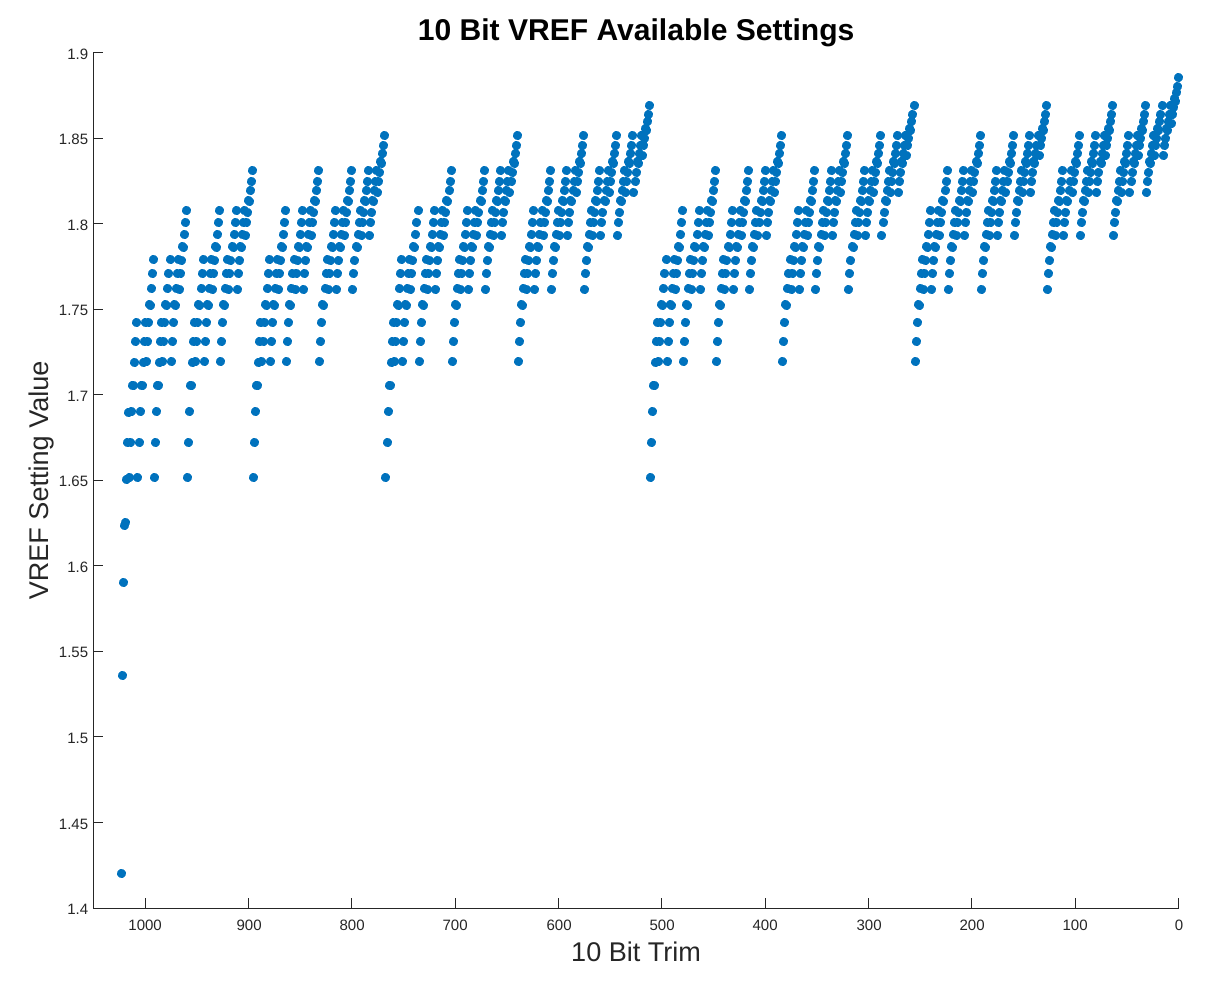

#### Comparator Latch
The Comparator is a clocked strong arm latch comparator which compares VREF and VREG, converting the error information into a digital output. This comparison information is then sent to the digital control logic. A comparator output low indicates that the VREG value is lower than the reference voltage VREF value. On the other hand, a comparator output high indicates that VREG is at higher voltage than VREF. 

A diagram of the latch is included below:

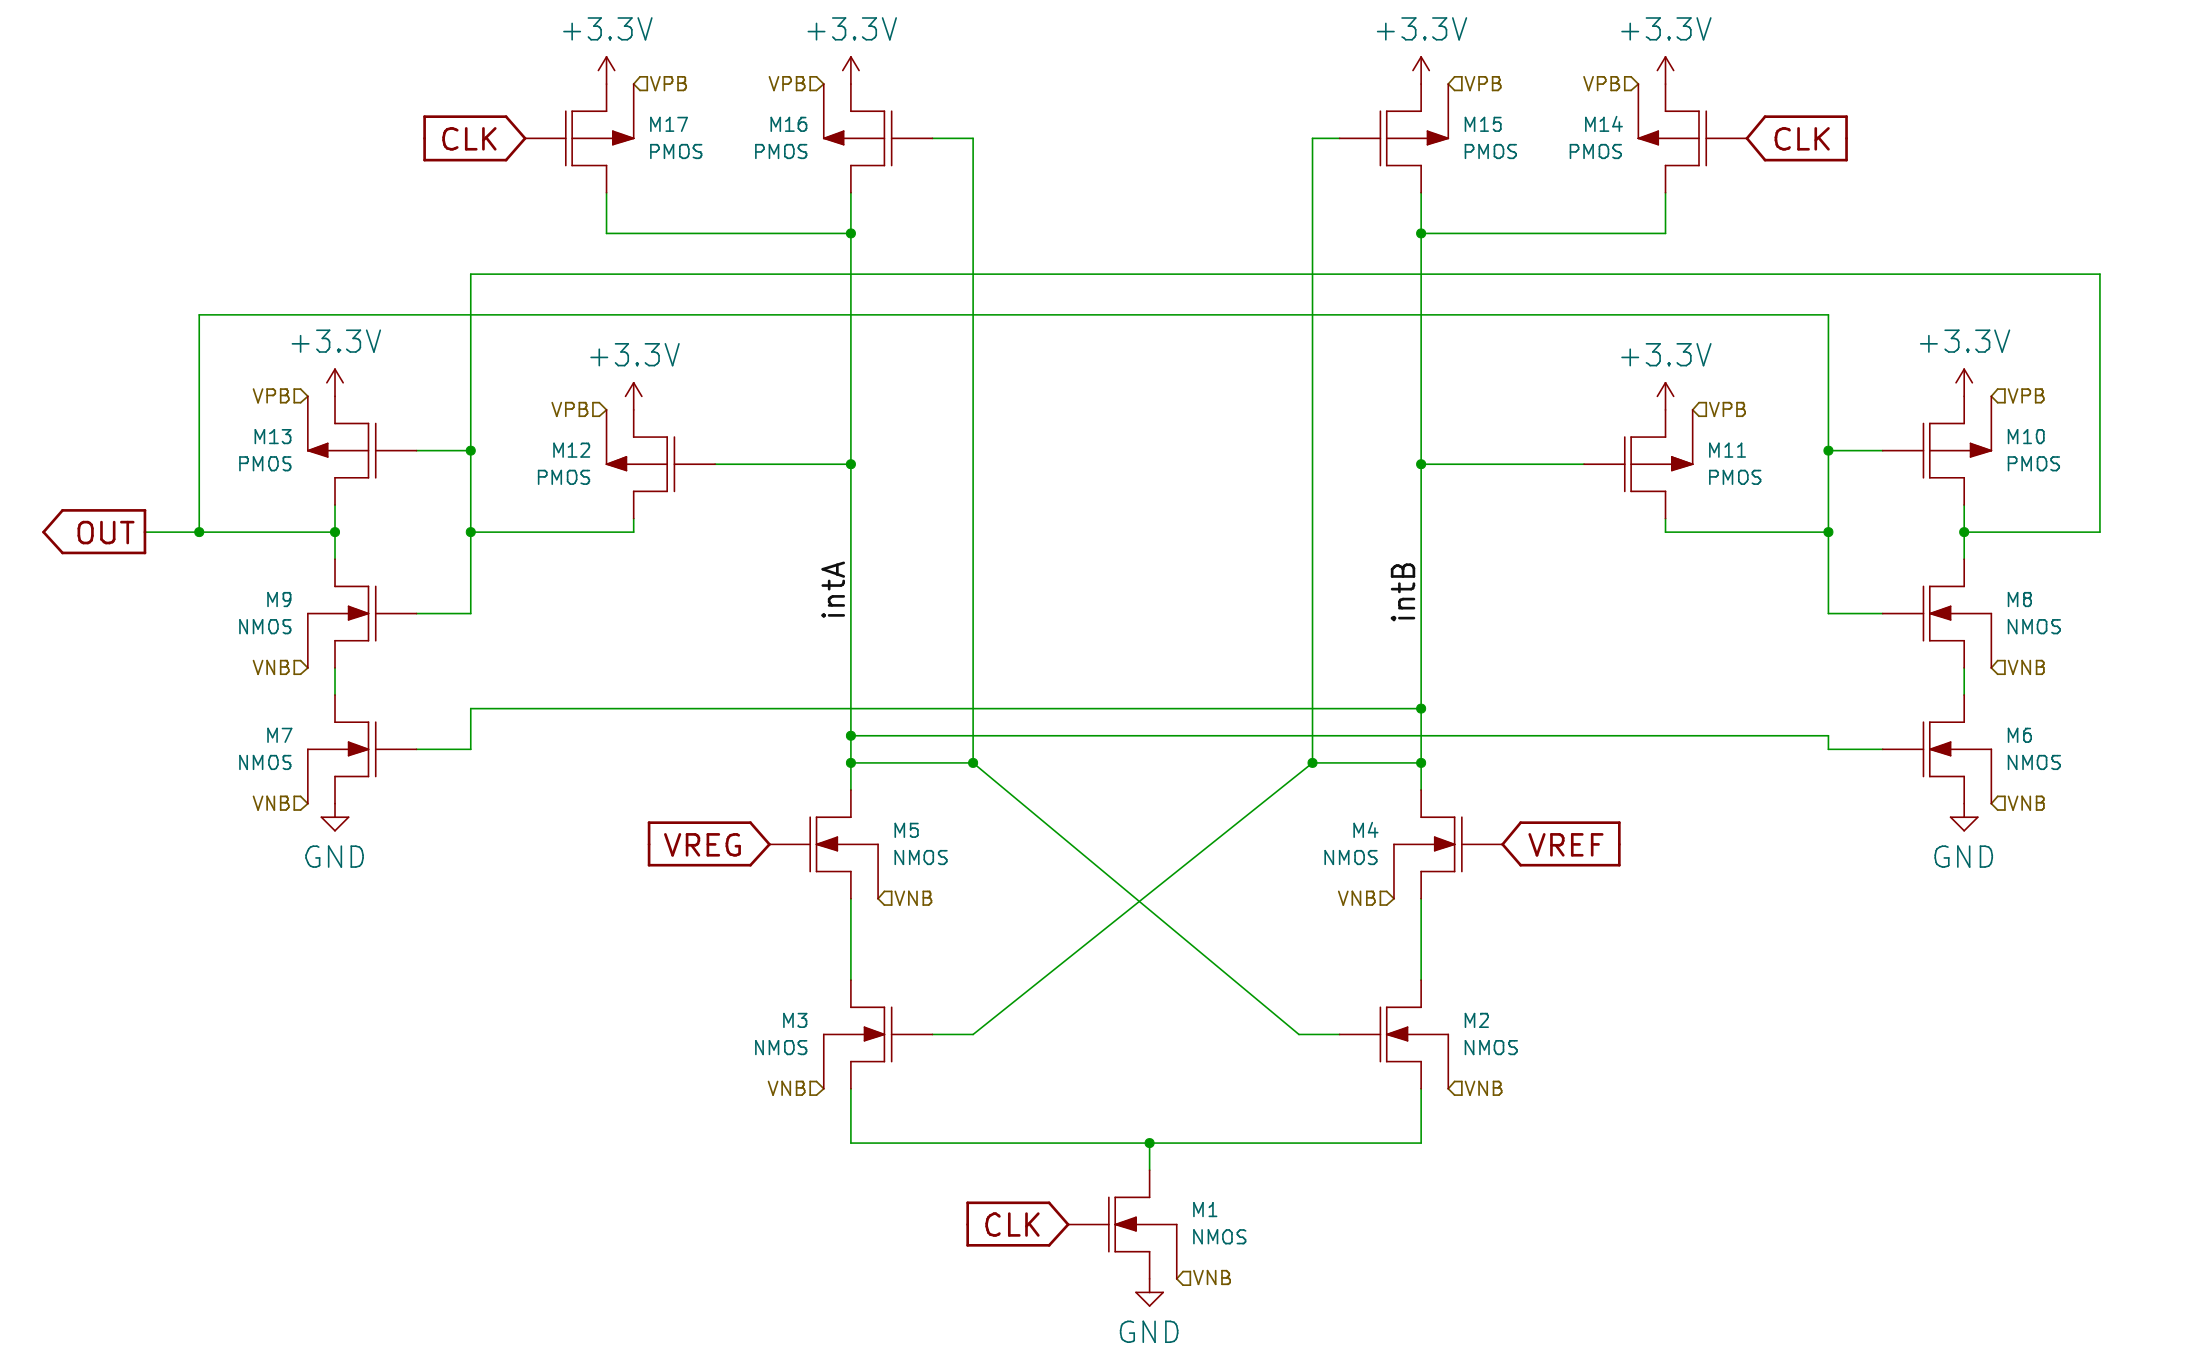

This is a strong arm latch optimal for low power. The design has very low static current consumption.

####Power Array Unit Cell 
The unit power array cell is a PMOS transistor combined with a NMOS transistor configured as a moscap. The unit cells act as current switches and are combined to form the power delivery array. 
####Capacitor 
The capacitor cells each provide an equivalent of 984 fF of capacitance. These cell are used to smoothen the output voltage during sudden load shifts. The LDO design incorporates 5 such capacitor cells.

### Digital Controller & Additional Notes
The power array controller is automatically generated from a verilog template. The generator python scripts parse user specs to determine the neccessary power array size. The verilog controller template is specialized in python. See flow below for details on the area optimizatios used in the automatic open source design. 

The digital controller receives the comparator information and adjusts the settings of each of the PMOS switches in the power array through the output control word (equal in size to the power array). Initially, all control bits in the output are set to a reset value (all high values) “1” in order to turn off all PMOS switches. The controller responds to inputs by shifting all control bits in the output register, then entering an additional high "1" voltage to turn off one more power switch, or an additional low "0" voltage to turn on one more power switch. 

The feedback cycle repeats each clock period. The power PMOS transistors act like current switches. Each current switch allows a fixed additional current to flow from VIN to VREG, thus increasing the voltage value of VREG.

Additionally, there are a number of current switches controlled directly by the comparator output. These direct control current switches help reduce transient response time. Additional direct control power switches (at a fixed array size) provide a trade off between latency and steady state oscillations. The number of directly controlled switches is determined automatically in the python script based on the array size; this controls the tradeoff between latency and steady state oscillations.

## Generator Flow: Multi Voltage Domain Design With Open Source Tools
Before running the flow, we must set up our python environment with the necessary open-source tools. The generator uses a flexible set of tools and will support even more in the future. In the below walkthrough, we will use:
*   Yosys for logic synthesis
*   Openroad for placing and routing
*   Klayout to produce the final GDS file
*   Magic for DRC and LVS checks as well as PEX
*   Ngspice for simulation

**There may be a restart runtime warning after this code block, but disregard.**

In [ ]:
# install all tools and dependencies
import os
import pathlib
import sys
!apt install -y time build-essential
!apt install qt5-default qttools5-dev libqt5xmlpatterns5-dev qtmultimedia5-dev libqt5multimediawidgets5 libqt5svg5-dev -y
!apt install ruby ruby-dev libz-dev python3-dev -y
!wget https://www.klayout.org/downloads/Ubuntu-20/klayout_0.28.3-1_amd64.deb
!dpkg -i klayout_0.28.3-1_amd64.deb
!curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba
conda_prefix_path = pathlib.Path('conda-env')
CONDA_PREFIX = str(conda_prefix_path.resolve())
%env CONDA_PREFIX={CONDA_PREFIX}
!bin/micromamba create --yes --prefix $CONDA_PREFIX
!bin/micromamba install --yes --prefix $CONDA_PREFIX \
                        --channel litex-hub \
                        --channel main \
                        open_pdks.sky130a \
                        openroad \
                        netgen \
                        magic \
                        yosys
!bin/micromamba install --yes --prefix $CONDA_PREFIX \
                        --channel conda-forge \
                        svgutils ngspice
!python -m pip install matplotlib ltspice pyyaml click gdstk cairosvg svgutils --no-binary gdstk pillow
# clone OpenFASOC repo and setup env
!git clone https://github.com/alibillalhammoud/OpenFASOC
OPENFASOC_ROOT=str(pathlib.Path('OpenFASOC').resolve())
LDO_ROOT=OPENFASOC_ROOT+"/openfasoc/generators/ldo-gen/"
!cp OpenFASOC/openfasoc/generators/ldo-gen/blocks/sky130hvl/gds/capacitor_test_nf.gds OpenFASOC/docs/source/notebooks/ldo-gen
!cp OpenFASOC/openfasoc/generators/ldo-gen/blocks/sky130hvl/gds/PMOS.gds OpenFASOC/docs/source/notebooks/ldo-gen
!cp OpenFASOC/openfasoc/generators/ldo-gen/blocks/sky130hvl/gds/PT_UNIT_CELL.gds OpenFASOC/docs/source/notebooks/ldo-gen
!cp OpenFASOC/openfasoc/generators/ldo-gen/blocks/sky130hvl/gds/vref_gen_nmos_with_trim.gds OpenFASOC/docs/source/notebooks/ldo-gen
!cp OpenFASOC/openfasoc/generators/ldo-gen/blocks/sky130hvl/gds/LDO_COMPARATOR_LATCH.gds OpenFASOC/docs/source/notebooks/ldo-gen
!cp OpenFASOC/docs/source/notebooks/aux_files/def2gds.py OpenFASOC/docs/source/notebooks/ldo-gen
!cp OpenFASOC/docs/source/notebooks/aux_files/dbtodef.tcl OpenFASOC/docs/source/notebooks/ldo-gen
!cp OpenFASOC/openfasoc/common/platforms/sky130hvl/gds/sky130_fd_sc_hvl.gds OpenFASOC/docs/source/notebooks/ldo-gen
!cp OpenFASOC/openfasoc/common/platforms/sky130hvl/fill.json OpenFASOC/docs/source/notebooks/ldo-gen
%env PDK_ROOT=/content/conda-env/share/pdk
os.environ['PATH'] += ":/content/conda-env/bin"

### Understanding User Input
The generator must first parse the user’s requirements into a high-level circuit description or verilog. Note that verilog is a circuit description type that uses theoretical constructs (like mathematical operators, if-else blocks, always @ blocks,... etc) to concisely describe circuits. User input parsing is implemented by reading from a JSON spec file directly in the ldo-gen repository. The JSON allows for specifying desired operating VREG and maximum load current (imax). The design is optimzed to this spec.  
Please input your desired operating specifications below and run the code cell:


In [ ]:
import json
#@title Code the Chip: Desired Max Load and Vreg
VREG = 1.8 #@param {type:"slider", min:1.8, max:2.8, step:0.1}
Iload = 0.001 #@param {type:"slider", min:0.001, max:0.01, step:0.000001}
with open("OpenFASOC/openfasoc/generators/ldo-gen/spec.json","r") as specfile:
  specjson = json.load(specfile)
specjson["specifications"]["vin"]=VREG
specjson["specifications"]["imax"]=Iload
with open("OpenFASOC/openfasoc/generators/ldo-gen/spec.json","w") as specfile:
  json.dump(specjson,specfile)

The below example uses the sky130 pdk. The generator already has a model file for this node. The model file is used to automatically optimize the design, including: determining the number of power transistors, number of direct control transistors, and design area.  
The model data is stored as a 10-degree polynomial (using polynomial coeficients). The model file ensures that the automatically generated designs meet the user-spec current requirment. This data is generated by testing the maximum load current at a sweep of reference voltages and load capabilities (power array sizes).  
See below for an illustration of the model file data:

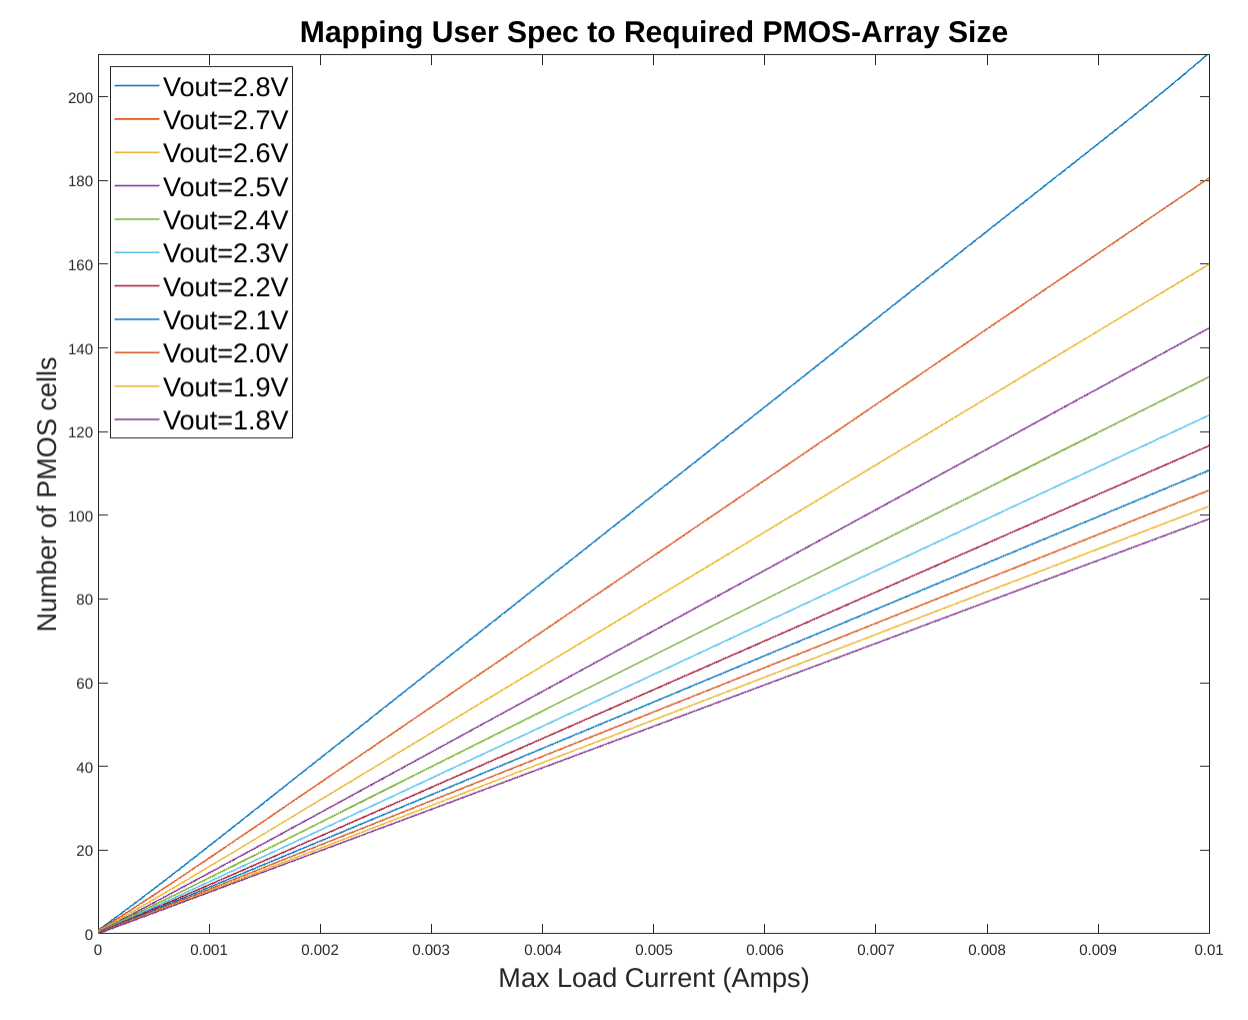

A verilog description is then produced by substituting specifics into several template verilog files. Additional files required by the Openroad flow are modified accordingly.

Run input parsing and verilog generation by running the code below and exploring the ldo-gen/src folder in your python virtual environment:

In [ ]:
!cd OpenFASOC/openfasoc/generators/ldo-gen && make clean
!cd OpenFASOC/openfasoc/generators/ldo-gen && make sky130hvl_ldo_verilog

rm -f error_within_x.csv golden_error_opt.csv search_result.csv
rm -rf work
rm -rf tools/*.pyc tools/__pycache__/
cd flow && make nuke
make[1]: Entering directory '/content/OpenFASOC/openfasoc/generators/ldo-gen/flow'
[INFO][FLOW] Using platform directory ../../../common/platforms/
Makefile:66: ../../../common/platforms//config.mk: No such file or directory
make[1]: *** No rule to make target '../../../common/platforms//config.mk'.  Stop.
make[1]: Leaving directory '/content/OpenFASOC/openfasoc/generators/ldo-gen/flow'
make: [Makefile:76: clean] Error 2 (ignored)
rm -f blocks/sky130hvl/ldo_custom_net.txt blocks/sky130hvl/ldo_domain_insts.txt
rm -rf ../../common/drc-lvs-check/sky130A
python3 ./tools/ldo-gen.py --output ./work --platform sky130hvl --mode verilog 
#---------------------------------------------------------------------
# Parsing command line arguments...
#---------------------------------------------------------------------
['./tools/ldo-gen.py', '--output', './work', '--pl

### Logic Synthesis
At this phase, the implementation of fundamental components — such as transistors and resistors — is not considered. Logic synthesis takes the verilog description from the previous step and outputs a more detailed netlist by parsing theoretical verilog constructs like always, case, if-else, operator, etc… blocks. Note that a netlist is just a list of pins and component connections. 

The YOSYS synthesis will generate the verilog netlist for the total design and a seperate verilog netlist for the LDO controller. The LDO controller is described as a verilog module because it is automatically generated from the template file (in the pyhthon scripts).

Later in the flow, there will be additional area optimizations and special routings done completley in the open-source flow tools (open-road). We also use python to complete some of the special routing during the flow (discussed below).

The generator treats the aux cells as macros to be inserted in the design during floorplan. At this stage, the verilog module instantions are used from "black-box" modules and included in the overall verilog netlist.

You can see the synthesis step by running the code below and viewing the ldo-gen/flow/results/sky130hvl/ldo/base/1_synth.v file in your python virtual environment:

In [ ]:
!cd OpenFASOC/openfasoc/generators/ldo-gen/flow && make synth

### Automatic Place and Route
Now that we have a description of our circuit which includes specific connections and components to use, it is possible to consider drawing the wires, placing the components, and choosing materials. Below is a step-by-step visual breakdown of the openroad APR.

#### Floorplan
First, an outline of the circuit is created encompassing the area that the circuit will occupy and including all the input and output pins for the top level circuit. Inside the LDO, power rails, tap, and decap cells are placed.

The configuration of the 5 capacitors and VREF block are fixed, but the large voltage domain will be made smaller or larger to optimze area based on the array size. During floorplan phase, several voltage domains are created using the open-road tcl script bindings. The open-road flow is used to create met5 straps which connect the ground and power rails directly to the large voltage domain rails. The VREG output of the LDO is created as a met5 power rail. VSS between the two voltage domains is shorted using met5 horizontal straps. 

You can view the above details by running floorplan and displaying gds below:

In [ ]:
!cd OpenFASOC/openfasoc/generators/ldo-gen/flow && make floorplan

OpenROAD b0c318df166641bffc7ad4f6822013dc5df3c5b7 
This program is licensed under the BSD-3 license. See the LICENSE file for details.
Components of this program may be licensed under more restrictive licenses which must be honored.
[INFO] Clearing cells...
[INFO] Merging GDS files...
	PMOS.gds
	PT_UNIT_CELL.gds
	vref_gen_nmos_with_trim.gds
	LDO_COMPARATOR_LATCH.gds
	capacitor_test_nf.gds
[INFO] Copying toplevel cell 'ldoInst'
INFO: Reading config file: fill.json
[INFO] Checking for missing GDS...
[ERROR] LEF Cell 'sky130_fd_sc_hvl__decap_4' has no matching GDS cell. Cell will be empty
[INFO] Writing out GDS 'out2.gds'


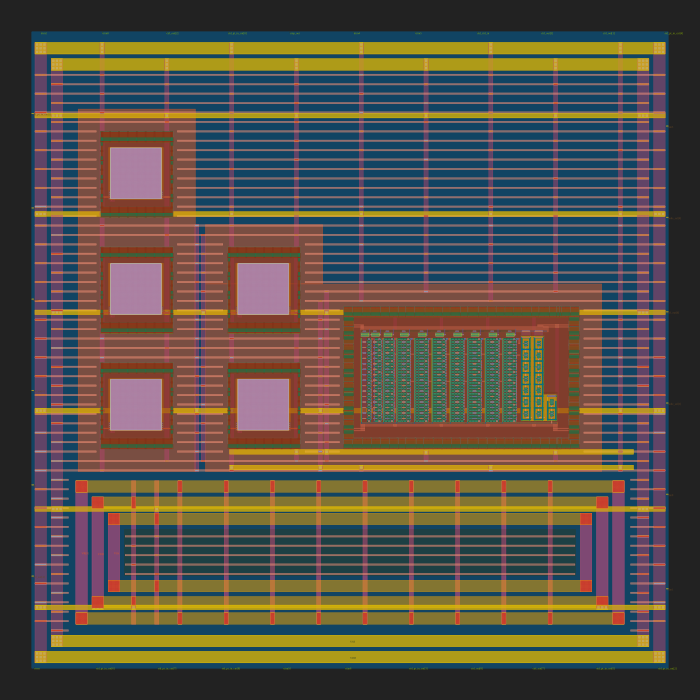

In [ ]:
import gdstk
import os
import IPython.display
import svgutils.transform as sg
# work dir setup
!cp OpenFASOC/openfasoc/generators/ldo-gen/flow/results/sky130hvl/ldo/base/2_floorplan.odb OpenFASOC/docs/source/notebooks/ldo-gen
os.environ['from_oprd_'] = '2_floorplan.odb'
os.environ['to_oprd_'] = 'out2.def'
# convert odb to def
!cd OpenFASOC/docs/source/notebooks/ldo-gen && openroad -no_init -exit dbtodef.tcl
# convert def to gds
!cd OpenFASOC/docs/source/notebooks/ldo-gen && klayout -zz -rd design_name=ldoInst \
	        -rd in_def="out2.def" \
	        -rd in_gds="PMOS.gds PT_UNIT_CELL.gds vref_gen_nmos_with_trim.gds LDO_COMPARATOR_LATCH.gds capacitor_test_nf.gds" \
	        -rd config_file="fill.json" \
	        -rd out_gds="out2.gds" \
	        -rd tech_file="klayout.lyt" \
	        -rm def2gds.py
!cp OpenFASOC/docs/source/notebooks/ldo-gen/out2.gds /content
flrpln = gdstk.read_gds("out2.gds".format(LDO_ROOT))
flrpln_top_cell = flrpln.top_level()
flrpln_top_cell[0].write_svg('out2.svg')
fig = sg.fromfile('out2.svg')
fig.set_size(('700','700'))
fig.save('out2.svg')
IPython.display.SVG('out2.svg')

####Place

The open-road tcl places the macros (auxcells) as blocked placement. The small domain contains the power arrays while the large domain contains the capacitors and the VREF gen block. Additionally, the digital controller and input buffers will all be placed within the large voltage domain.

Run place and render a polygon graphic for this stage by executing the code below:

In [ ]:
!cd OpenFASOC/openfasoc/generators/ldo-gen/flow && make place

OpenROAD b0c318df166641bffc7ad4f6822013dc5df3c5b7 
This program is licensed under the BSD-3 license. See the LICENSE file for details.
Components of this program may be licensed under more restrictive licenses which must be honored.
[INFO] Clearing cells...
[INFO] Merging GDS files...
	PMOS.gds
	PT_UNIT_CELL.gds
	vref_gen_nmos_with_trim.gds
	LDO_COMPARATOR_LATCH.gds
	capacitor_test_nf.gds
	sky130_fd_sc_hvl.gds
[INFO] Copying toplevel cell 'ldoInst'
INFO: Reading config file: fill.json
[INFO] Checking for missing GDS...
[INFO] All LEF cells have matching GDS cells
[INFO] Writing out GDS 'out3.gds'


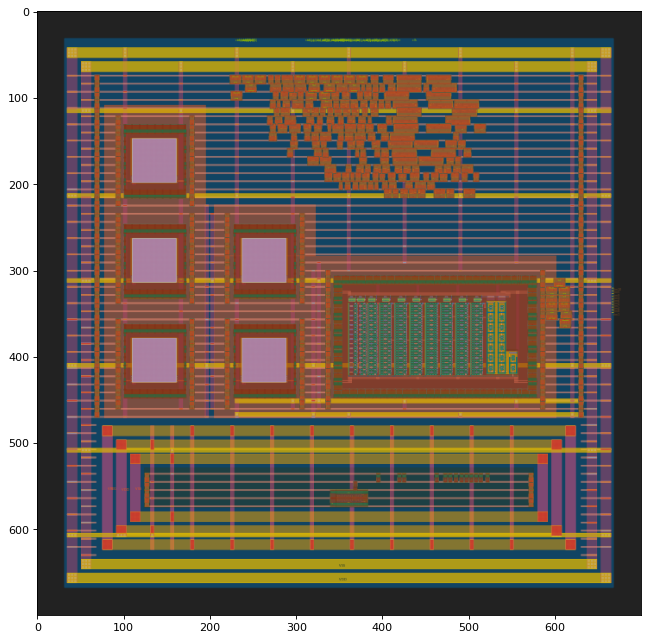

In [ ]:
import gdstk
import IPython.display
import svgutils.transform as sg
from cairosvg import svg2png
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
# work dir setup
!cp OpenFASOC/openfasoc/generators/ldo-gen/flow/results/sky130hvl/ldo/base/3_place.odb OpenFASOC/docs/source/notebooks/ldo-gen
os.environ['from_oprd_'] = '3_place.odb'
os.environ['to_oprd_'] = 'out3.def'
# convert odb to def
!cd OpenFASOC/docs/source/notebooks/ldo-gen && openroad -no_init -exit dbtodef.tcl
# convert def to gds
!cd OpenFASOC/docs/source/notebooks/ldo-gen && klayout -zz -rd design_name=ldoInst \
	        -rd in_def="out3.def" \
	        -rd in_gds="PMOS.gds PT_UNIT_CELL.gds vref_gen_nmos_with_trim.gds LDO_COMPARATOR_LATCH.gds capacitor_test_nf.gds sky130_fd_sc_hvl.gds" \
	        -rd config_file="fill.json" \
	        -rd out_gds="out3.gds" \
	        -rd tech_file="klayout.lyt" \
	        -rm def2gds.py
!cp OpenFASOC/docs/source/notebooks/ldo-gen/out3.gds /content
flrpln = gdstk.read_gds("out3.gds".format(LDO_ROOT))
flrpln_top_cell = flrpln.top_level()
flrpln_top_cell[0].write_svg('out3.svg')
fig = sg.fromfile('out3.svg')
fig.set_size(('700','700'))
fig.save('out3.svg')
fname = "out3"
svg2png(url=fname+".svg",write_to=fname+".png")
plt.figure(figsize=(10,10),dpi=80)
img = mpimg.imread(fname+".png")
plt.imshow(img) 
plt.show()

#### CTS
CTS stands for clock tree synthesis (balancing a clock delay to all parts of a circuit). The CLK input to LDO is buffered and routed to the internal clock node.  
Additionally, filler cells are placed during this step. Filler cells ensure that there are continous silicon p and n wells — among other manufacturing and performance reasons. Fillers are placed to fill the gaps.

Run CTS and render a polygon graphic for this stage by executing the code below:

In [ ]:
!cd OpenFASOC/openfasoc/generators/ldo-gen/flow && make cts

OpenROAD b0c318df166641bffc7ad4f6822013dc5df3c5b7 
This program is licensed under the BSD-3 license. See the LICENSE file for details.
Components of this program may be licensed under more restrictive licenses which must be honored.
[INFO] Clearing cells...
[INFO] Merging GDS files...
	PMOS.gds
	PT_UNIT_CELL.gds
	vref_gen_nmos_with_trim.gds
	LDO_COMPARATOR_LATCH.gds
	capacitor_test_nf.gds
	sky130_fd_sc_hvl.gds
[INFO] Copying toplevel cell 'ldoInst'
INFO: Reading config file: fill.json
[INFO] Checking for missing GDS...
[INFO] All LEF cells have matching GDS cells
[INFO] Writing out GDS 'out4.gds'


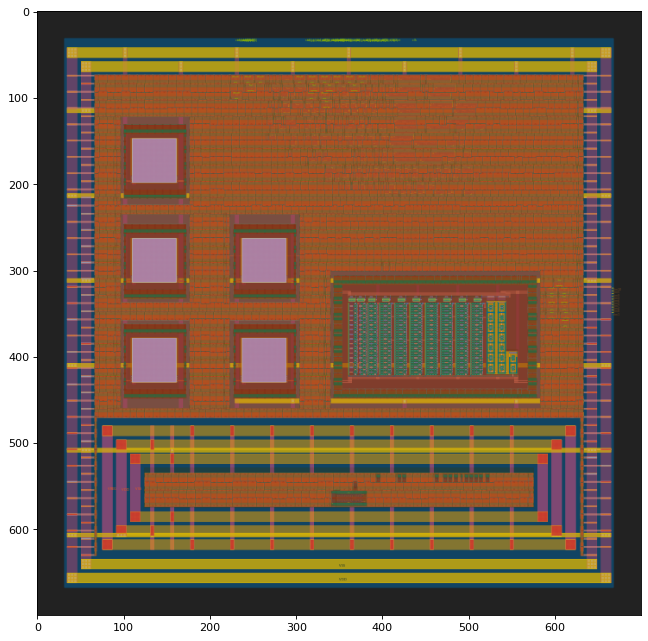

In [ ]:
import gdstk
import IPython.display
import svgutils.transform as sg
from cairosvg import svg2png
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
# work dir setup
!cp OpenFASOC/openfasoc/generators/ldo-gen/flow/results/sky130hvl/ldo/base/4_cts.odb OpenFASOC/docs/source/notebooks/ldo-gen
os.environ['from_oprd_'] = '4_cts.odb'
os.environ['to_oprd_'] = 'out4.def'
# convert odb to def
!cd OpenFASOC/docs/source/notebooks/ldo-gen && openroad -no_init -exit dbtodef.tcl
# convert def to gds
!cd OpenFASOC/docs/source/notebooks/ldo-gen && klayout -zz -rd design_name=ldoInst \
	        -rd in_def="out4.def" \
	        -rd in_gds="PMOS.gds PT_UNIT_CELL.gds vref_gen_nmos_with_trim.gds LDO_COMPARATOR_LATCH.gds capacitor_test_nf.gds sky130_fd_sc_hvl.gds" \
	        -rd config_file="fill.json" \
	        -rd out_gds="out4.gds" \
	        -rd tech_file="klayout.lyt" \
	        -rm def2gds.py
!cp OpenFASOC/docs/source/notebooks/ldo-gen/out4.gds /content
flrpln = gdstk.read_gds("out4.gds".format(LDO_ROOT))
flrpln_top_cell = flrpln.top_level()
flrpln_top_cell[0].write_svg('out4.svg')
fig = sg.fromfile('out4.svg')
fig.set_size(('700','700'))
fig.save('out4.svg')
fname = "out4"
svg2png(url=fname+".svg",write_to=fname+".png")
plt.figure(figsize=(10,10),dpi=80)
img = mpimg.imread(fname+".png")
plt.imshow(img) 
plt.show()

####Routing
The last step is to connect the components. During routing, wire-like pathways known as traces are placed in the design.

To achieve special routes between the power large rails and VREG output using the open-road tools, we encorporate python scripts to provide a custom route to the VREG. There is a similar custom route for the VREF node to the comparator input. Run floorplan and render a polygon graphic for this stage by executing the code below.

Run route and finish then render a graphic by executing the code below:

In [ ]:
!cd OpenFASOC/openfasoc/generators/ldo-gen/flow && make finish

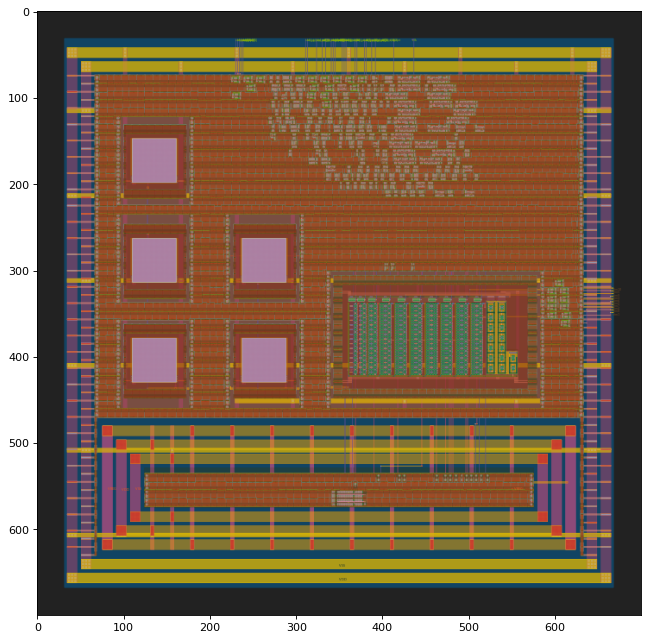

In [ ]:
import gdstk
import IPython.display
import svgutils.transform as sg
from cairosvg import svg2png
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
!cp OpenFASOC/openfasoc/generators/ldo-gen/flow/results/sky130hvl/ldo/base/6_final.gds /content
flrpln = gdstk.read_gds("6_final.gds".format(LDO_ROOT))
flrpln_top_cell = flrpln.top_level()
flrpln_top_cell[0].write_svg('6_final.svg')
fig = sg.fromfile('6_final.svg')
fig.set_size(('700','700'))
fig.save('6_final.svg')
fname = "6_final"
svg2png(url=fname+".svg",write_to=fname+".png")
plt.figure(figsize=(10,10),dpi=80)
img = mpimg.imread(fname+".png")
plt.imshow(img) 
plt.show()

### DRC and LVS
Now that the generator has completed the flow, an automatic checking process is initiated. DRC or design rule checking ensures that the final circuit obeys manufacturing rules. Rules are set by the foundry for each of their nodes. LVS or layout vs schematic will compare the final output from APR to the netlist that we gave the APR tool (in this case Openroad). This ensures that APR ran correctly and our final circuit matches our netlist description from logic synthesis. Both of these steps will use magic (LVS will also run on magic).

Run checks by executing the below code. Both checks will give command line output below with complete status:

In [ ]:
!cd OpenFASOC/openfasoc/generators/ldo-gen/flow && make magic_drc
!cd OpenFASOC/openfasoc/generators/ldo-gen/flow && make netgen_lvs

## Simulations
The LDO generator has an automatic testbench suite to verify design functionality. The below simulations include parasitics and run on several operating configurations. All of the below simulations are performed at several VREG output capacitances. Additionally, simulations are run on different operating frequencies between 100KHz up to 10 MHz.  
After running the below simulation code, you can display each simulation result by running subsequent code blocks.

**_Note:_** This block will run simulations. This may take over 30 minutes.

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
import subprocess as sp
!cd /content/OpenFASOC/openfasoc/generators/ldo-gen && make clean_sims
!cd /content/OpenFASOC/openfasoc/generators/ldo-gen && python ./tools/ldo-gen.py --output ./work --platform sky130hvl --mode sim

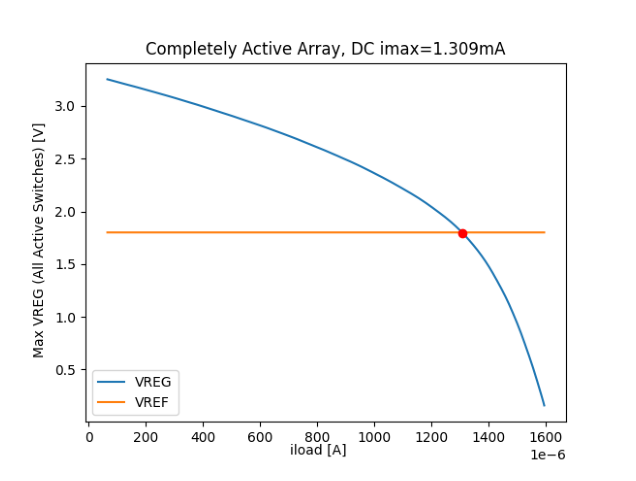

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
def disp_img(fpathin):
  plt.figure(figsize=(10,10),dpi=80)
  plt.axis('off')
  img = mpimg.imread(fpathin)
  plt.imshow(img)
  plt.show()
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/dc.png")

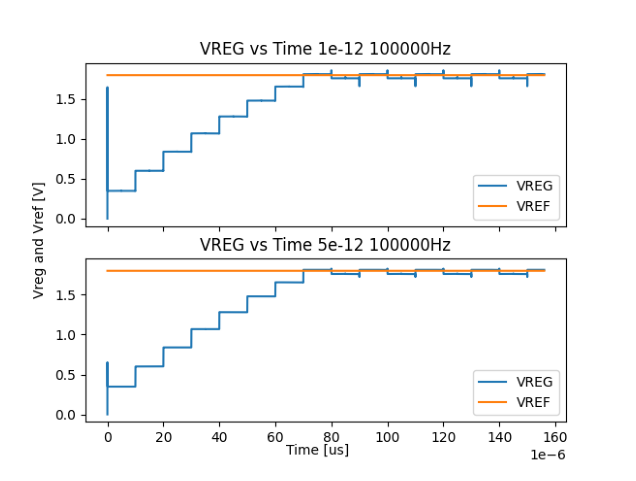

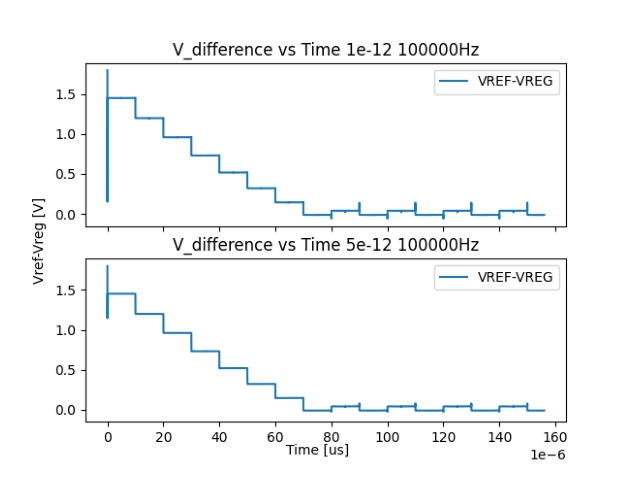

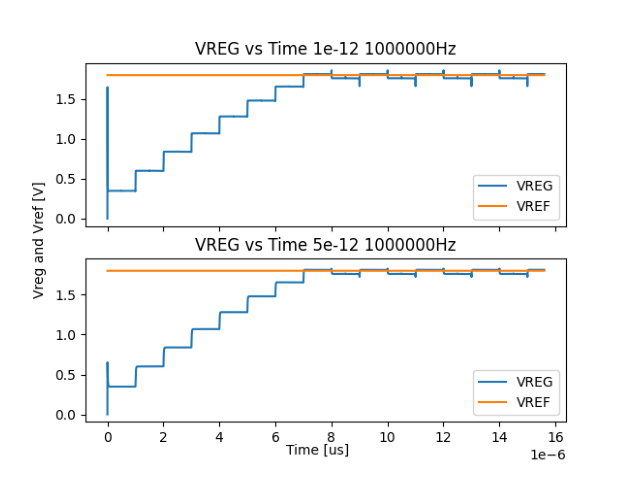

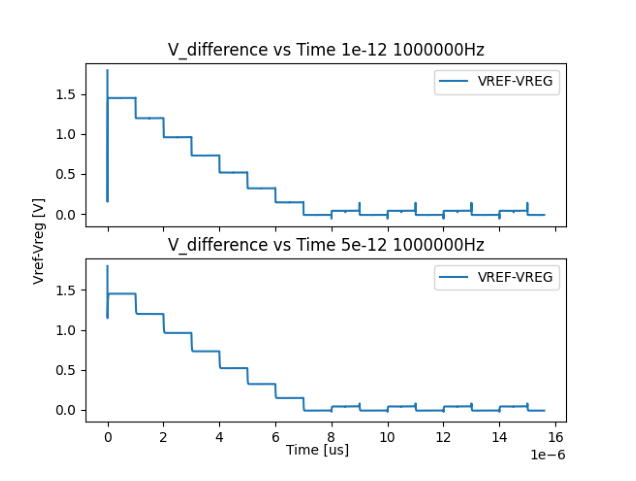

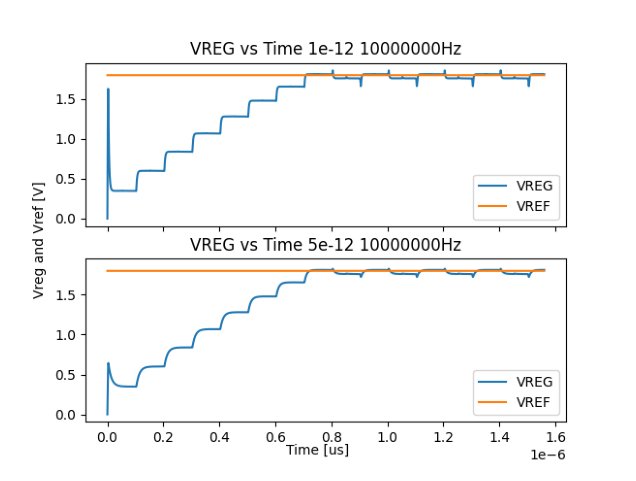

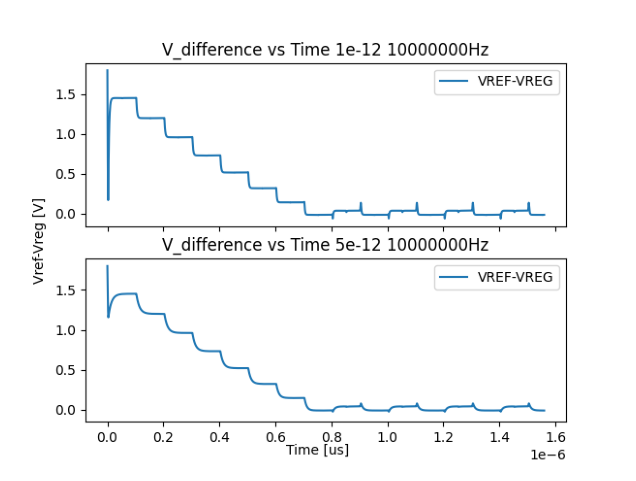

In [ ]:
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/100000Hz/VREG_output.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/100000Hz/VDIF.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/1000000Hz/VREG_output.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/1000000Hz/VDIF.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/10000000Hz/VREG_output.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/10000000Hz/VDIF.png")

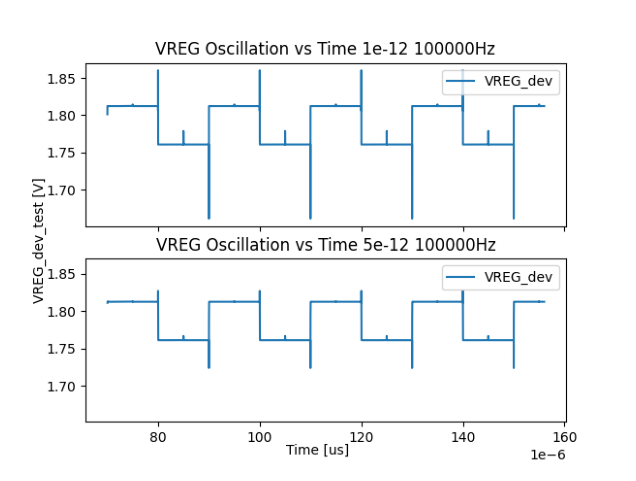

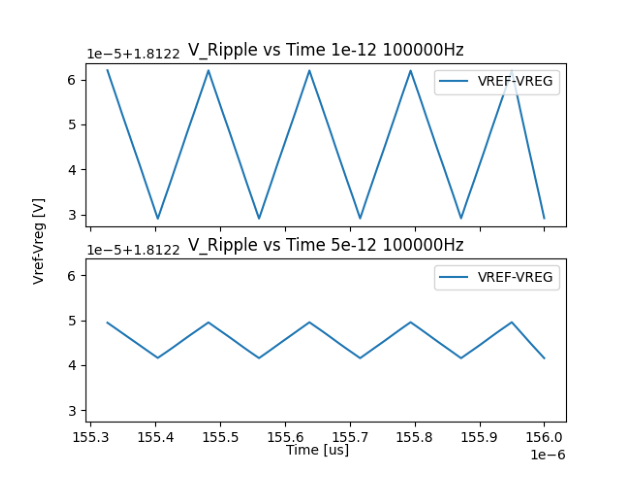

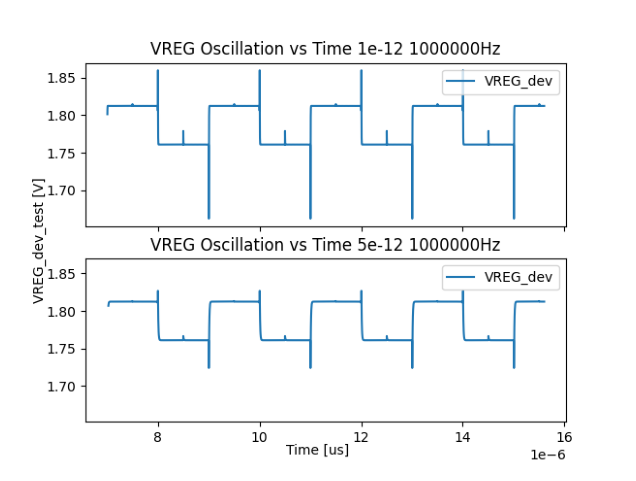

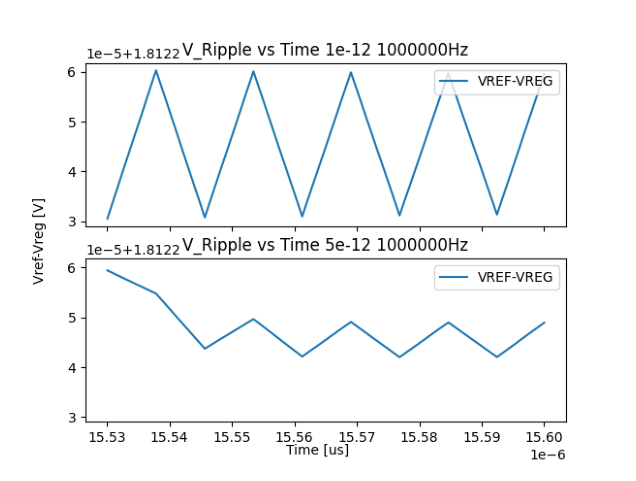

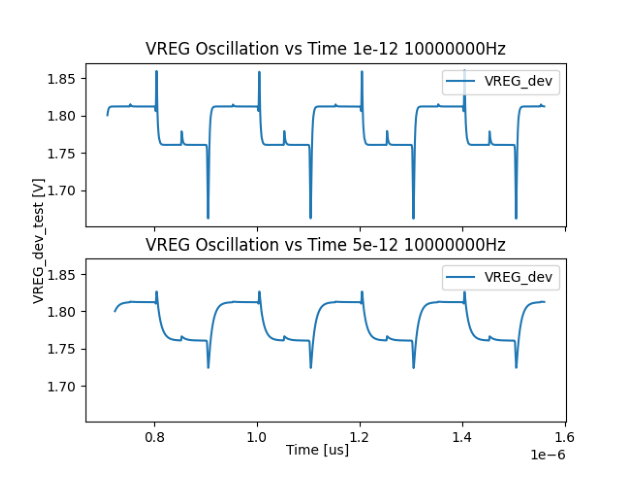

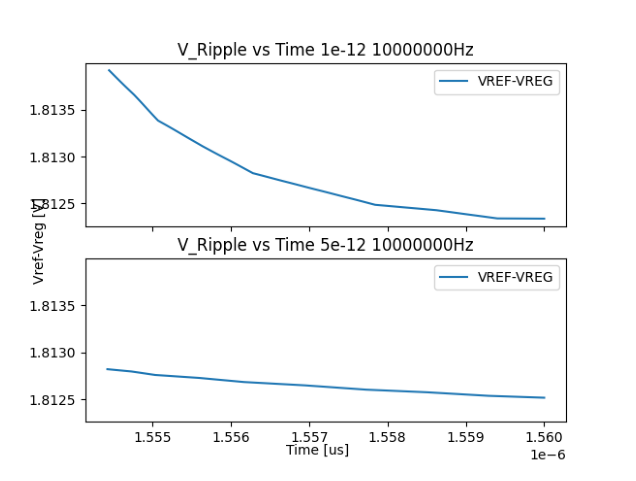

In [ ]:
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/100000Hz/VREG_oscillation.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/100000Hz/VREG_ripple.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/1000000Hz/VREG_oscillation.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/1000000Hz/VREG_ripple.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/10000000Hz/VREG_oscillation.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/10000000Hz/VREG_ripple.png")

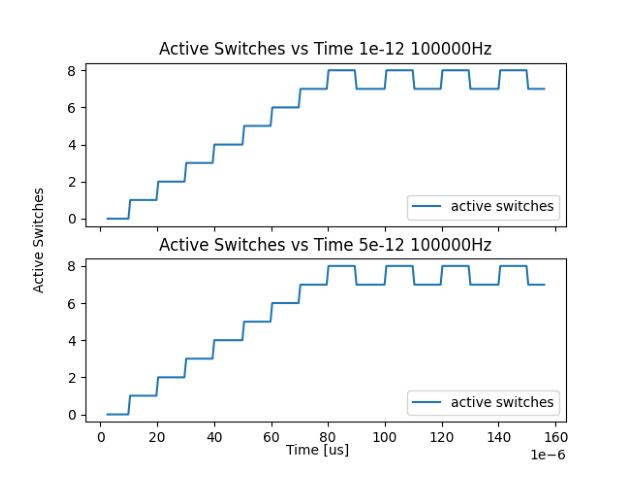

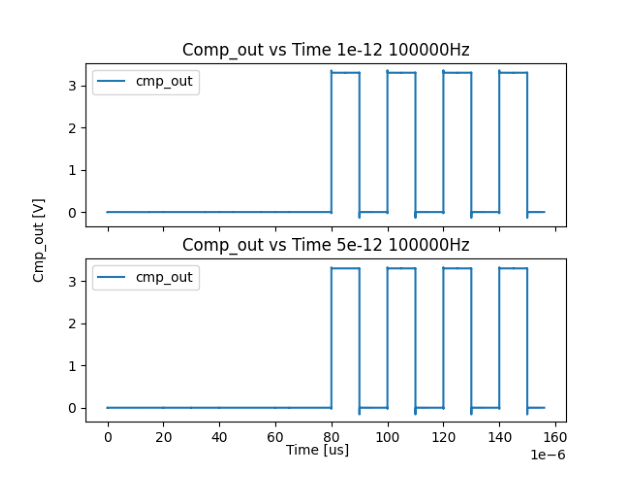

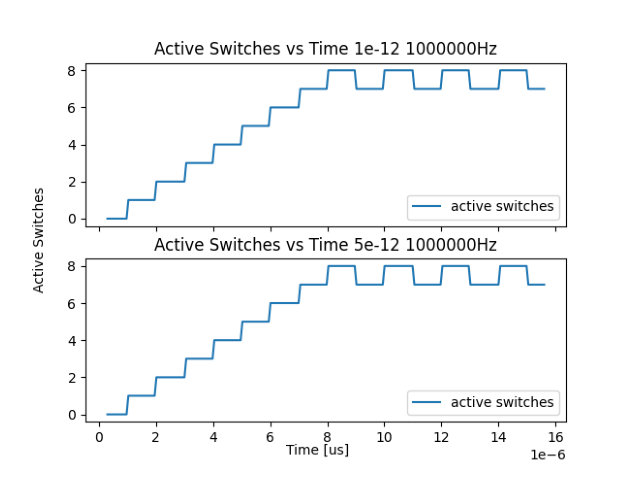

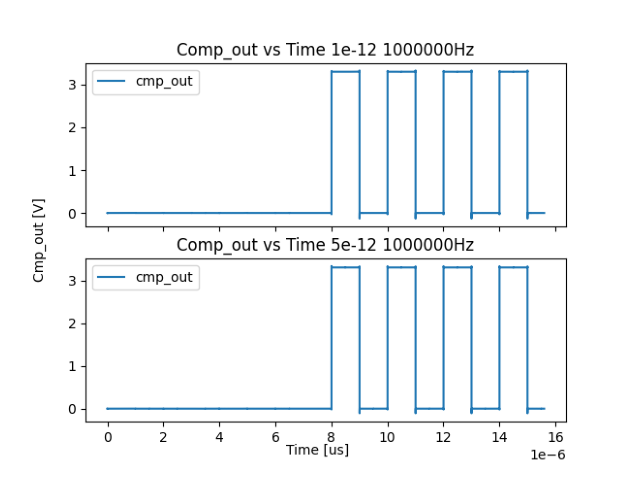

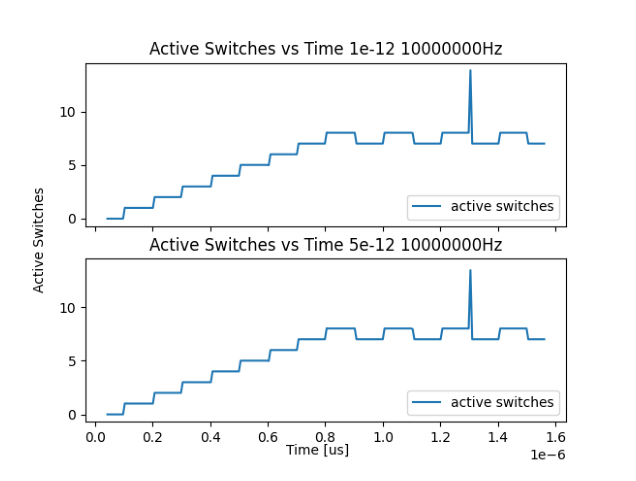

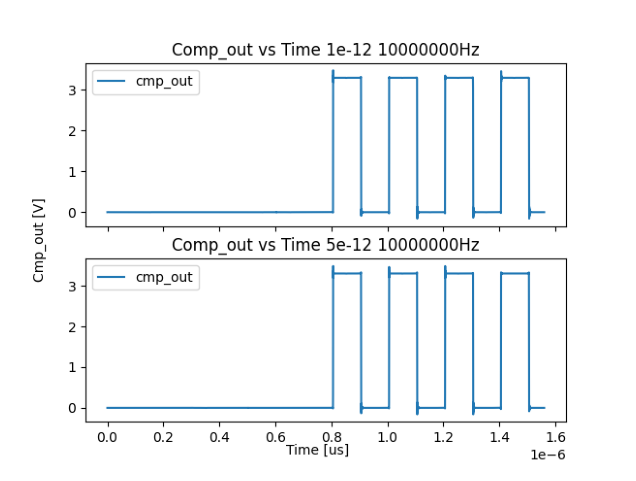

In [ ]:
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/100000Hz/active_switches.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/100000Hz/cmp_out.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/1000000Hz/active_switches.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/1000000Hz/cmp_out.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/10000000Hz/active_switches.png")
disp_img("/content/OpenFASOC/openfasoc/generators/ldo-gen/work/10000000Hz/cmp_out.png")